In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load dataset
df = pd.read_csv("stockData.csv")

# Display first rows
df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD
0,HSI,31/12/86,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0,333.879006
1,HSI,02/01/87,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0,330.213013
2,HSI,05/01/87,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0,331.811987
3,HSI,06/01/87,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0,335.906987
4,HSI,07/01/87,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0,338.923013


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104224 entries, 0 to 104223
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      104224 non-null  str    
 1   Date       104224 non-null  str    
 2   Open       104224 non-null  float64
 3   High       104224 non-null  float64
 4   Low        104224 non-null  float64
 5   Close      104224 non-null  float64
 6   Adj Close  104224 non-null  float64
 7   Volume     104224 non-null  int64  
 8   CloseUSD   104224 non-null  float64
dtypes: float64(6), int64(1), str(2)
memory usage: 8.4 MB


In [4]:
df.isnull().sum()

Index        0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
CloseUSD     0
dtype: int64

In [5]:
# Select numeric columns
features = df[['Open', 'High', 'Low', 'Close', 'Volume']]

features.head()

,Open,High,Low,Close,Volume
0,2568.300049,2568.300049,2568.300049,2568.300049,0
1,2540.100098,2540.100098,2540.100098,2540.100098,0
2,2552.399902,2552.399902,2552.399902,2552.399902,0
3,2583.899902,2583.899902,2583.899902,2583.899902,0
4,2607.100098,2607.100098,2607.100098,2607.100098,0


In [6]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-0.59592382, -0.59751049, -0.59390563, -0.59581285, -0.30437112],
       [-0.59900897, -0.60057686, -0.59701042, -0.59889799, -0.30437112],
       [-0.59766334, -0.59923942, -0.59565622, -0.59755236, -0.30437112],
       [-0.59421714, -0.59581422, -0.5921881 , -0.59410619, -0.30437112],
       [-0.59167897, -0.59329151, -0.58963378, -0.59156803, -0.30437112]])

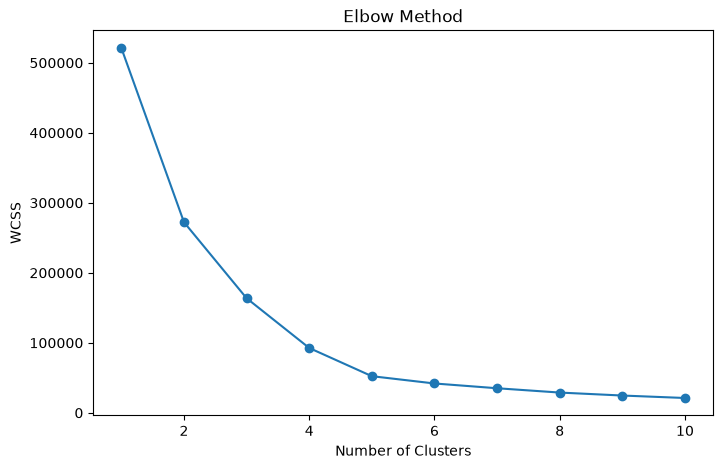

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters

df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD,Cluster
0,HSI,31/12/86,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0,333.879006,0
1,HSI,02/01/87,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0,330.213013,0
2,HSI,05/01/87,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0,331.811987,0
3,HSI,06/01/87,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0,335.906987,0
4,HSI,07/01/87,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0,338.923013,0


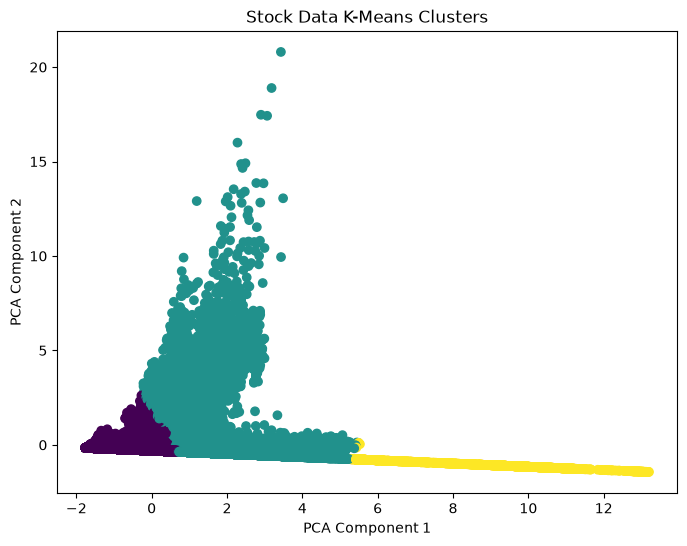

In [9]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Stock Data K-Means Clusters")

plt.show()

In [10]:
score = silhouette_score(
    scaled_features,
    df['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.6035566326465452


In [13]:
stop_words = set(stopwords.words('english'))
df.to_csv(
    "stockData_clustered.csv",
    index=False
)

print("File saved successfully")

File saved successfully


In [ ]:
tfidf = TfidfVectorizer(
    max_features=1000
)

text_features = tfidf.fit_transform(
    df['Clean_Text']
)

text_features.shape

In [ ]:
text_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

text_clusters = text_kmeans.fit_predict(
    text_features
)

df['Text_Cluster'] = text_clusters

df[['News','Text_Cluster']].head()